In [2]:
import uproot
import pandas as pd
import numpy as np
import glob


In [3]:
import matplotlib.pyplot as plt
plt.style.use('default')
plt.style.use('belle2')

import os

In [4]:
import glob

base_path = "/share/storage/jykim/storage_b2/storage/reduced_ntuples/proc13/proc13_Kspip_loose_v7_250228"
cm_elements = ["Kshp_13_had_4S_off_v1", "Kshp_13_had_4S_v3", "Kshp_23_had_4S_off_v1", "Kshp_23_had_4S_v1", "Kshp_23_had_5Sscan_10657_v1", "Kshp_23_had_5Sscan_10706_v1",\
               "Kshp_23_had_5Sscan_10751_v1", "Kshp_23_had_5Sscan_10810_v1"]

cut_expression = "Dp_M>0"
ref_tree = "etapip_pipipi"
tree_name = "Ks"
file_list = []
for element in cm_elements:
    # pattern = f"{base_path}/{element}/*.root"
    pattern = f"{base_path}/{element}/{ref_tree}/{tree_name}/apply_bdt/*.BCS.root"

    file_list += glob.glob(pattern)


dataframes = []
# Process each file
for file_name in file_list:
    # Load the ROOT file and tree
    file = uproot.open(file_name)
    tree = file[tree_name]

    # Specify the branches you want to extract
    # branches = ['Pip_pionID','Dp_Psum','Pip_genMotherID','etapip_Eta_genMotherID','Pip_genMotherPDG','etapip_Eta_genMotherPDG','Dp_cosHelicityAngleMomentum','Pip_dr',"Dp_isSignal","Dp_cosAngleBetweenMomentumAndVertexVectorInXYPlane", "Pip_p","Dp_CMS_p","etapip_Eta_p","CFT_prob","Dp_M","num_Dstar_no_nan",]  # Replace with actual branch names

    branches = ['Dp_M','Dp_CMS_cosTheta','Pip_cosTheta','Pip_p','Pip_charge','BDT']
    # Convert the selected branches to a Pandas DataFrame
    # df_temp = tree.arrays(branches, library="pd")
    df_temp = tree.arrays(
        branches,
        library="pd",
        entry_start=None,  # Optional: start at a specific entry
        entry_stop=None,   # Optional: stop at a specific entry
        filter_name=branches,  # Load only specified branches
        cut=cut_expression  # Apply the cut
    )
    # df_temp = tree.arrays(library="pd")

    # Append the DataFrame to the list
    dataframes.append(df_temp)

In [5]:
df_proc13 = pd.concat(dataframes, ignore_index=True)


In [6]:
df_proc13.describe()

,Dp_M,Dp_CMS_cosTheta,Pip_cosTheta,Pip_p,Pip_charge,BDT
count,5.275257e+06,5.275257e+06,5.275257e+06,5.275257e+06,5.275257e+06,5.275257e+06
mean,1.845874e+00,6.700749e-02,3.315770e-01,1.456877e+00,-1.829484e-03,3.498874e-01
std,1.307842e-01,5.534421e-01,4.977219e-01,1.057167e+00,9.999984e-01,3.198318e-01
min,1.600000e+00,-9.999974e-01,-9.044896e-01,4.000000e-01,-1.000000e+00,1.298503e-03
25%,1.740552e+00,-4.229938e-01,-4.592998e-02,5.569170e-01,-1.000000e+00,7.589454e-02
50%,1.862181e+00,9.341547e-02,4.561199e-01,1.002635e+00,-1.000000e+00,2.186886e-01
75%,1.941910e+00,5.624660e-01,7.677093e-01,2.241443e+00,1.000000e+00,6.098118e-01
max,2.100000e+00,9.999999e-01,9.794338e-01,1.573749e+01,1.000000e+00,9.964882e-01


In [7]:
df_proc13 = df_proc13.query('Dp_M> 1.80 & Dp_M<1.93')


In [8]:
df_proc13.describe()

,Dp_M,Dp_CMS_cosTheta,Pip_cosTheta,Pip_p,Pip_charge,BDT
count,1.896648e+06,1.896648e+06,1.896648e+06,1.896648e+06,1.896648e+06,1.896648e+06
mean,1.865779e+00,7.753272e-02,3.250819e-01,1.574340e+00,-2.442203e-03,4.377007e-01
std,3.090792e-02,5.483269e-01,4.967427e-01,1.068137e+00,9.999973e-01,3.521902e-01
min,1.800000e+00,-9.999974e-01,-8.999475e-01,4.000000e-01,-1.000000e+00,1.592348e-03
25%,1.846644e+00,-4.029396e-01,-5.850608e-02,6.116086e-01,-1.000000e+00,9.728981e-02
50%,1.868791e+00,1.084602e-01,4.438005e-01,1.269404e+00,-1.000000e+00,3.330243e-01
75%,1.882072e+00,5.650541e-01,7.637078e-01,2.360657e+00,1.000000e+00,8.299110e-01
max,1.930000e+00,9.999932e-01,9.794338e-01,1.250819e+01,1.000000e+00,9.964882e-01


In [9]:
nan_columns = df_proc13.isnull().any()
print(nan_columns)

Dp_M               False
Dp_CMS_cosTheta    False
Pip_cosTheta       False
Pip_p              False
Pip_charge         False
BDT                False
dtype: bool


In [11]:
import glob

base_path = "/share/storage/jykim/storage_b2/storage/reduced_ntuples/MC15rd/Kspip/MC15rd_Kspip_loose_v7_1_250228_Dp_CMS_p"
cm_elements = ["MCrd_Ks_e7_18_4S_v3", "MCrd_Ks_e20_b26_v1", "MCrd_Ks_e20_e26_4S_v2", "MCrd_Ks_e21_5S_scan_v1", "MCrd_Ks_mori_off_v1"]

cut_expression = "Dp_M>0"
ref_tree = "etapip_pipipi"
tree_name = "Ks"

file_list = []
for element in cm_elements:
    # pattern = f"{base_path}/{element}/*.root"
    pattern = f"{base_path}/{element}/{ref_tree}/{tree_name}/apply_bdt/*.BCS.root"

    file_list += glob.glob(pattern)


dataframes = []
# Process each file
for file_name in file_list:
    # Load the ROOT file and tree
    file = uproot.open(file_name)
    tree = file[tree_name]

    # Specify the branches you want to extract
    # branches = ['Pip_pionID','Dp_Psum','Pip_genMotherID','etapip_Eta_genMotherID','Pip_genMotherPDG','etapip_Eta_genMotherPDG','Dp_cosHelicityAngleMomentum','Pip_dr',"Dp_isSignal","Dp_cosAngleBetweenMomentumAndVertexVectorInXYPlane", "Pip_p","Dp_CMS_p","etapip_Eta_p","CFT_prob","Dp_M","num_Dstar_no_nan",]  # Replace with actual branch names

    branches = ['Dp_M','Dp_CMS_cosTheta','Pip_cosTheta','Pip_p','Pip_charge','BDT']
    # Convert the selected branches to a Pandas DataFrame
    # df_temp = tree.arrays(branches, library="pd")
    df_temp = tree.arrays(
        branches,
        library="pd",
        entry_start=None,  # Optional: start at a specific entry
        entry_stop=None,   # Optional: stop at a specific entry
        filter_name=branches,  # Load only specified branches
        cut=cut_expression  # Apply the cut
    )
    # df_temp = tree.arrays(library="pd")

    # Append the DataFrame to the list
    dataframes.append(df_temp)

In [12]:
df_mc15rd = pd.concat(dataframes, ignore_index=True)


In [13]:
df_mc15rd.describe()

,Dp_M,Dp_CMS_cosTheta,Pip_cosTheta,Pip_p,Pip_charge,BDT
count,2.182180e+07,2.182180e+07,2.182180e+07,2.182180e+07,2.182180e+07,2.182180e+07
mean,1.840422e+00,5.474414e-02,3.154471e-01,1.496630e+00,3.021291e-04,3.322090e-01
std,1.315434e-01,5.467978e-01,4.960403e-01,1.076315e+00,1.000000e+00,3.113356e-01
min,1.600000e+00,-9.999998e-01,-9.083980e-01,4.000000e-01,-1.000000e+00,1.288346e-03
25%,1.732843e+00,-4.266650e-01,-6.724392e-02,5.783278e-01,-1.000000e+00,7.211708e-02
50%,1.851828e+00,7.140458e-02,4.297140e-01,1.040344e+00,1.000000e+00,2.011786e-01
75%,1.937854e+00,5.432855e-01,7.522289e-01,2.307272e+00,1.000000e+00,5.574545e-01
max,2.100000e+00,9.999999e-01,9.814150e-01,3.003157e+01,1.000000e+00,9.965822e-01


In [14]:
df_mc15rd = df_mc15rd.query('Dp_M> 1.80 & Dp_M<1.93')


In [15]:
df_mc15rd.describe()

,Dp_M,Dp_CMS_cosTheta,Pip_cosTheta,Pip_p,Pip_charge,BDT
count,7.442115e+06,7.442115e+06,7.442115e+06,7.442115e+06,7.442115e+06,7.442115e+06
mean,1.864852e+00,6.147287e-02,3.110514e-01,1.598283e+00,6.295253e-04,4.022061e-01
std,3.201642e-02,5.442393e-01,4.957183e-01,1.084752e+00,9.999999e-01,3.440674e-01
min,1.800000e+00,-9.999998e-01,-9.083980e-01,4.000001e-01,-1.000000e+00,1.329210e-03
25%,1.842617e+00,-4.142155e-01,-7.596847e-02,6.239563e-01,-1.000000e+00,8.668837e-02
50%,1.868208e+00,8.084804e-02,4.213211e-01,1.274918e+00,1.000000e+00,2.754401e-01
75%,1.883247e+00,5.450196e-01,7.501211e-01,2.407161e+00,1.000000e+00,7.644935e-01
max,1.930000e+00,9.999999e-01,9.791014e-01,2.252845e+01,1.000000e+00,9.965822e-01


In [16]:
nan_columns = df_mc15rd.isnull().any()
print(nan_columns)

Dp_M               False
Dp_CMS_cosTheta    False
Pip_cosTheta       False
Pip_p              False
Pip_charge         False
BDT                False
dtype: bool


In [17]:
from plothist import make_hist, plot_hist
from plothist import plot_two_hist_comparison, add_luminosity, plot_error_hist


/home/jykim/.local/lib/python3.10/site-packages/IPython/core/interactiveshell.py:3378: UserWarning: The recommended fonts to use plothist were not found. You can install them by typing 'install_latin_modern_fonts' in your terminal. If it still does not work, please check the documentation at https://plothist.readthedocs.io/en/latest/usage/font_installation.html
  exec(code_obj, self.user_global_ns, self.user_ns)


In [18]:
tree_to_compare = tree_name
plt.rcParams['font.family'] = 'DejaVu Sans'


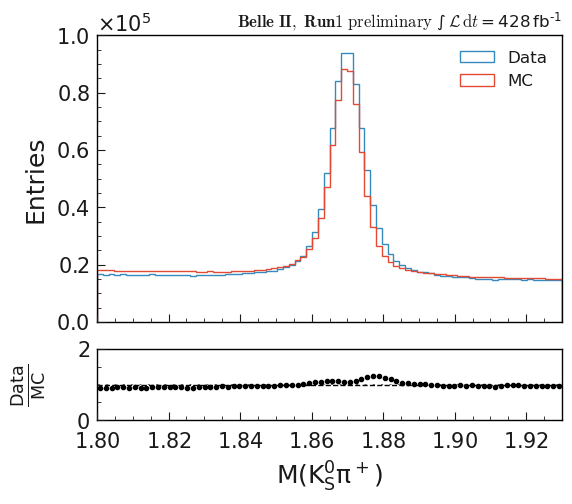

In [19]:
name = "Dp_M"
category = "category"
xlabel = r"$M(K_S^0 \pi^+)$"

# x1 = df[name][df[category] == 1]
# x2 = df[name][df[category] == 2]

x1 = df_proc13[name]
x2 = df_mc15rd[name]

# x_range = (min(min(x1), min(x2)), max(max(x1), max(x2)))
# x_range = (min(min(x1), min(x2)),5.1)
x_range = (1.80,1.93)

h1 = make_hist(x1, bins=80, range=x_range, weights=1)
h2 = make_hist(x2, bins=80, range=x_range, weights=1/4)


# Default comparison is ratio
fig, ax_main, ax_comparison = plot_two_hist_comparison(
    h1,
    h2,
    xlabel=xlabel,
    ylabel="Entries",
    h1_label="Data",
    h2_label="MC",
    comparison="split_ratio",
)
# plot_error_hist(h1, ax=ax_main, color="black", label="$h1_{err}$")

add_luminosity(
    collaboration="Belle II, Run1", ax=ax_main, lumi=428, lumi_unit="fb", preliminary=True
)
fig.savefig(f"proc13_MC15rd_{tree_to_compare}_{ref_tree}_{name}_no_bdt.png", bbox_inches="tight")

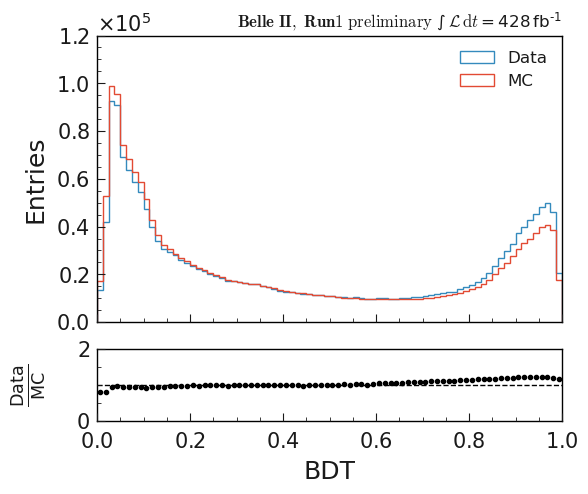

In [20]:
name = "BDT"
category = "category"
xlabel = r"BDT"

# x1 = df[name][df[category] == 1]
# x2 = df[name][df[category] == 2]

x1 = df_proc13[name]
x2 = df_mc15rd[name]

# x_range = (min(min(x1), min(x2)), max(max(x1), max(x2)))
# x_range = (min(min(x1), min(x2)),5.1)
x_range = (0,1)

h1 = make_hist(x1, bins=80, range=x_range, weights=1)
h2 = make_hist(x2, bins=80, range=x_range, weights=1/4)


# Default comparison is ratio
fig, ax_main, ax_comparison = plot_two_hist_comparison(
    h1,
    h2,
    xlabel=xlabel,
    ylabel="Entries",
    h1_label="Data",
    h2_label="MC",
    comparison="split_ratio",
)
# plot_error_hist(h1, ax=ax_main, color="black", label="$h1_{err}$")

add_luminosity(
    collaboration="Belle II, Run1", ax=ax_main, lumi=428, lumi_unit="fb", preliminary=True
)
fig.savefig(f"proc13_MC15rd_{tree_to_compare}_{ref_tree}_{name}_no_bdt.png", bbox_inches="tight")